# Exploring Aerosol In-situ Data: PNSD, ACSM, and Filter Absorption Photometer Measurements

## Introducton

This notebook series provides a hands-on guide for working with atmospheric aerosol datasets relevant to ACTRIS In-Situ. It focuses on three key types of in-situ data: Particle Number Size Distributions (PNSD), Aerosol Chemical Speciation Monitor (ACSM) data, and Filter Absorption Photometer measurements.

This notebook handles Aerosol Chemical Speciation Monitor (ACSM) measurements. 

Students will learn how to:
* Search for and extract relevant datasets,
* Join datasets from the same station,
* Perform basic plotting and visualization.

The aim is to equip you with practical skills for accessing, combining, and analyzing aerosol in-situ observational data. A basic understanding of Python, especially libraries such as pandas and matplotlib, is expected to follow the exercises effectively.

### Import libaries

In [3]:
# Import necessary libraries
import json  # For working with JSON files
import requests  # For making HTTP requests
import os  # For handling file system operations

import xarray as xr  # For working with multidimensional datasets
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations

import matplotlib.pyplot as plt  # For plotting and visualization
import matplotlib.dates as mdates  # For formatting dates in plots
import plotly.graph_objects as go  # For creating advanced visualizations
import plotly.express as px  # For simpler visualizations

from tqdm.notebook import tqdm  # For creating progress bars
from datetime import datetime  # For working with date and time

## ACSM dataset

In [4]:
# Get all metadata from particle mass spectrometer instruments at Birkenes II, Norway
i = 0
metadata_archive = []
pbar = tqdm(desc="Fetching metadata pages", unit="page") # create a progress bar

while True:
    response = requests.get(f"https://prod-actris-md2.nilu.no/metadata/instrument/particle%20mass%20spectrometer/country/NO/facility/9cxe/page/{i}") 
    if not response.json():
        break
    metadata_archive += response.json()
    i += 1
    pbar.update(1)

pbar.close()

Fetching metadata pages: 0page [00:00, ?page/s]

In [5]:
# Extract content information from metadata
files_list = []
for f in metadata_archive:
    time = f["ex_temporal_extent"]
    inst = {"instrument_model": f["md_actris_specific"]["instrument_model"]}
    combined_dict = {**time, **inst}  # Merge the dictionaries
    files_list.append(combined_dict)

df_content_information = pd.DataFrame.from_records(files_list)
# Display the content information for all datasets
df_content_information

,time_period_begin,time_period_end,instrument_model
0,2012-08-08T00:00:00,2018-12-31T00:00:00,Aerodyne/Q-ACSM
1,2019-10-16T00:00:00,2020-04-16T00:00:00,Aerodyne/Q-ACSM
2,2023-01-03T00:00:00,2024-01-01T00:00:00,Aerodyne/Q-ACSM


In [6]:
acsm_ds = xr.open_dataset(metadata_archive[0]['md_distribution_information'][1]['dataset_url'])
acsm_ds

<xarray.Dataset>
Dimensions:                                              (time: 56073,
                                                          tbnds: 2,
                                                          metadata_time: 1,
                                                          ammonium_ug_N_per_m3_amean_qc_flags: 1,
                                                          ammonium_ug_per_m3_amean_qc_flags: 1,
                                                          ammonium_ug_N_per_m3_uncertainty_qc_flags: 1,
                                                          ...
                                                          organic_mass_amean_Fraction_qc_flags: 1,
                                                          organic_mass_uncertainty_Fraction_qc_flags: 1,
                                                          sulphate_total_ug_S_per_m3_amean_qc_flags: 1,
                                                          sulphate_total_ug_per_m3_amean_qc_flags: 1,
                                                          sulphate_total_ug_S_per_m3_uncertainty_qc_flags: 1,
                                                          sulphate_total_ug_per_m3_uncertainty_qc_flags: 1)
Coordinates:
  * time                                                 (time) datetime64[ns] ...
  * metadata_time                                        (metadata_time) datetime64[ns] ...
  * Fraction                                             (Fraction) |S64 b'Or...
Dimensions without coordinates: tbnds, ammonium_ug_N_per_m3_amean_qc_flags,
                                ammonium_ug_per_m3_amean_qc_flags,
                                ammonium_ug_N_per_m3_uncertainty_qc_flags,
                                ammonium_ug_per_m3_uncertainty_qc_flags,
                                nitrate_ug_N_per_m3_amean_qc_flags,
                                nitrate_ug_per_m3_amean_qc_flags,
                                ...
                                organic_mass_amean_Fraction_qc_flags,
                                organic_mass_uncertainty_Fraction_qc_flags,
                                sulphate_total_ug_S_per_m3_amean_qc_flags,
                                sulphate_total_ug_per_m3_amean_qc_flags,
                                sulphate_total_ug_S_per_m3_uncertainty_qc_flags,
                                sulphate_total_ug_per_m3_uncertainty_qc_flags
Data variables: (12/50)
    time_bnds                                            (time, tbnds) datetime64[ns] ...
    metadata_time_bnds                                   (metadata_time, tbnds) datetime64[ns] ...
    ammonium_ug_N_per_m3_amean                           (time) float64 ...
    ammonium_ug_N_per_m3_amean_qc                        (ammonium_ug_N_per_m3_amean_qc_flags, time) float64 ...
    ammonium_ug_N_per_m3_amean_ebasmetadata              (metadata_time) |S64 ...
    ammonium_ug_per_m3_amean                             (time) float64 ...
    ...                                                   ...
    sulphate_total_ug_S_per_m3_uncertainty_ebasmetadata  (metadata_time) |S64 ...
    sulphate_total_ug_per_m3_uncertainty                 (time) float64 ...
    sulphate_total_ug_per_m3_uncertainty_qc              (sulphate_total_ug_per_m3_uncertainty_qc_flags, time) float64 ...
    sulphate_total_ug_per_m3_uncertainty_ebasmetadata    (metadata_time) |S64 ...
    organic_mass_amean_Fraction                          (Fraction, time) float64 ...
    organic_mass_uncertainty_Fraction                    (Fraction, time) float64 ...
Attributes: (12/110)
    Conventions:                        CF-1.8, ACDD-1.3
    featureType:                        timeSeries
    title:                              Inorganics in air and particle phase ...
    keywords:                           ammonium, NILU, mass_concentration_of...
    id:                                 YPU8-HCC3.nc
    naming_authority:                   EBAS
    ...                                 ...
    geo

In [7]:
# Combine datasets with the same instrument model into one xarray Dataset
datasets = []

# Loop through the relevant indices (1 to 5)
for idx in range(0, 3):
    dataset_url = metadata_archive[idx]['md_distribution_information'][1]['dataset_url']
    ds = xr.open_dataset(dataset_url)  # Open the dataset

    # Drop all variables with '_qc' in their names to avoid conflicts
    # This is to clean up datasets before merging
    variables_to_drop = [var for var in ds.data_vars if '_qc' in var]
    ds = ds.drop_vars(variables_to_drop)

    datasets.append(ds)  # Append to the list

# Merge all datasets into one xarray Dataset
combined_ds = xr.concat(datasets, dim='time')

combined_ds

<xarray.Dataset>
Dimensions:                                                (metadata_time: 4,
                                                            Fraction: 5,
                                                            time: 69177,
                                                            tbnds: 2,
                                                            Fractionx: 3,
                                                            Location: 1)
Coordinates:
  * metadata_time                                          (metadata_time) datetime64[ns] ...
  * Fraction                                               (Fraction) |S64 b'...
  * time                                                   (time) datetime64[ns] ...
  * Location                                               (Location) |S64 b'...
  * Fractionx                                              (Fractionx) |S64 b...
Dimensions without coordinates: tbnds
Data variables: (12/48)
    time_bnds                                              (time, tbnds) datetime64[ns] ...
    metadata_time_bnds                                     (time, metadata_time, tbnds) datetime64[ns] ...
    ammonium_ug_N_per_m3_amean                             (time) float64 0.2...
    ammonium_ug_N_per_m3_amean_ebasmetadata                (time, metadata_time) object ...
    ammonium_ug_per_m3_amean                               (time) float64 0.3...
    ammonium_ug_per_m3_amean_ebasmetadata                  (time, metadata_time) object ...
    ...                                                     ...
    nitrate_ug_per_m3_uncertainty_Fraction_ebasmetadata    (time, Fraction, metadata_time) object ...
    pressure                                               (Location, time) float64 ...
    nitrate_ug_N_per_m3_amean_Fraction                     (Fraction, time) float64 ...
    nitrate_ug_per_m3_amean_Fraction                       (Fraction, time) float64 ...
    nitrate_ug_N_per_m3_uncertainty_Fraction               (Fraction, time) float64 ...
    nitrate_ug_per_m3_uncertainty_Fraction                 (Fraction, time) float64 ...
Attributes: (12/110)
    Conventions:                        CF-1.8, ACDD-1.3
    featureType:                        timeSeries
    title:                              Inorganics in air and particle phase ...
    keywords:                           ammonium, NILU, mass_concentration_of...
    id:                                 YPU8-HCC3.nc
    naming_authority:                   EBAS
    ...                                 ...
    geospatial_lat_units:               degrees_north
    geospatial_lon_units:               degrees_east
    comment:                            {\n    "Data definition": "EBAS_1.1",...
    standard_name_vocabulary:           CF-1.7, ACDD-1.3
    history:                            None
    creator_url:                        ebas.nilu.no

In [8]:
ds = combined_ds # Choose acsm_ds or combined_ds

variables2plot = []

# Iterate over each variable in the dataset
for v in list(ds.data_vars.keys()):
    attrs = ds[v].attrs
    # Check if the variable has 'ebas_statistics' as 'arithmetic mean' and 'units' as 'ug/m3'
    if attrs.get('ebas_statistics') == 'arithmetic mean' and attrs.get('units') == 'ug/m3':
        # Check if the variable does not have dimensions 'Fraction', 'Fractionx', 'Fractionxx'
        if all(dim not in ds[v].dims for dim in ['Fraction', 'Fractionx', 'Fractionxx']):
            variables2plot.append(v)  # Add the variable to the list of variables to plot

variables2plot

['ammonium_ug_per_m3_amean',
 'nitrate_ug_per_m3_amean',
 'organic_mass_amean',
 'sulphate_total_ug_per_m3_amean',
 'chloride_amean']

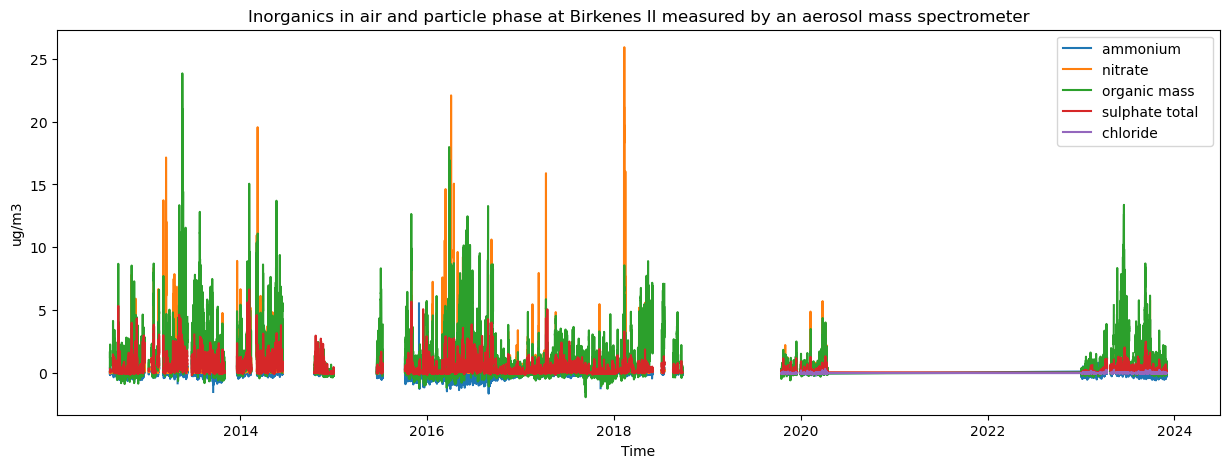

In [ ]:
# Define the function to plot variables
def plot_variables(variables, dataset):
    # Set up the figure and axes
    plt.figure(figsize=(15,5))
    plt.xlabel('Time')
    
    # Iterate over each variable and plot it
    for v in variables:
        units = dataset[v].attrs['units']  # Get the units of the variable
        y = dataset.variables[v].data  # Get the data for the variable
        x = dataset.variables['time'].data  # Get the time data
        plt.plot(x, y, label=v.replace('amean','').replace('ug_per_m3','').replace('_', ' '))  # Plot the variable data
    
    # Set the y-axis label, legend, and title
    plt.ylabel(units)
    plt.legend()
    plt.title('{} measured by an {}'.format(dataset.attrs['title'], dataset.attrs['ebas_instrument_type'].replace('_', ' ')))    
    
    dd# Show the plot
    plt.show()

# Call the function to plot the variables
plot_variables(variables2plot, ds)